# Source similarity

Construct bipartite graph:  
Nodes:  
- sources 
- Cantus IDs (CID)
Edges:
- edge between source and feast is present, if some chants dedicated to such feast are present in the catalogued source
- edge weight == log2(number of chants with unique CIDs)

Run SBM for weighted graph - try both basic and nested PLUS degree corrected versions.

In [1]:
import utils

In [2]:
import pycantus
import pycantus.data as data

In [3]:
corpus = data.load_dataset('cantuscorpus_v1.0')

Loading chants and sources...
Data loaded!


In [4]:
n_chants = len(corpus.chants)
print(f'Number of chants in CantusCorpus v1.0: {n_chants}')
n_sources = len(corpus.sources)
print(f'Number of sources in CantusCorpus v1.0: {n_sources}')

Number of chants in CantusCorpus v1.0: 888010
Number of sources in CantusCorpus v1.0: 2278


In [5]:
# Drop doxology
doxo_filter = pycantus.filtration.Filter('doxo_filter')
doxo_filter.add_value_exclude('cantus_id', '909000')
corpus.apply_filter(doxo_filter)

In [6]:
MIN_CHANTS_PER_SOURCE = 100

In [7]:
# Drop fragments => sources with less than 100 chants
corpus.drop_small_sources_data(min_chants=MIN_CHANTS_PER_SOURCE)

In [8]:
n_chants = len(corpus.chants)
print(f'Number of chants in CantusCorpus v1.0: {n_chants}')
n_sources = len(corpus.sources)
print(f'Number of sources in CantusCorpus v1.0: {n_sources}')

Number of chants in CantusCorpus v1.0: 855146
Number of sources in CantusCorpus v1.0: 510


In [72]:
sigla_dict = {source.srclink: source.siglum for source in corpus.sources}

Create network

In [73]:
import importlib
importlib.reload(utils)

<module 'utils' from '/home/watticka/network_analysis/project/ChantNets/experiments/utils.py'>

In [74]:
graph = utils.construct_bipart_source_feast_graph(corpus)

Constructing bipartite graph between sources and feasts...
Number of source nodes: 507
Number of feast nodes: 2371
Number of source-feast edges: 65700


In [14]:
utils.save_graph(graph, f"nets/source_feast_bi_graph_min_{MIN_CHANTS_PER_SOURCE}.gt")

### Add SBM

In [45]:
import sbmodel
importlib.reload(sbmodel)

<module 'sbmodel' from '/home/watticka/network_analysis/project/ChantNets/experiments/sbmodel.py'>

In [46]:
model = sbmodel.SBModel()
model.load_graph(f"nets/source_feast_bi_graph_min_{MIN_CHANTS_PER_SOURCE}.gt")

Loaded graph with 2878 vertices, 65700 edges


In [47]:
N_INIT = 20

In [48]:
model.fit_sbm(n_init=N_INIT)

Fitting SBM to graph with 2878 vertices and 65700 edges...
Fitting SBM (init 1/20)...
[1/20] entropy = 134819.86
Fitting SBM (init 2/20)...
[2/20] entropy = 134959.05
Fitting SBM (init 3/20)...
[3/20] entropy = 134920.18
Fitting SBM (init 4/20)...
[4/20] entropy = 134945.24
Fitting SBM (init 5/20)...
[5/20] entropy = 134884.36
Fitting SBM (init 6/20)...
[6/20] entropy = 135028.69
Fitting SBM (init 7/20)...
[7/20] entropy = 134999.66
Fitting SBM (init 8/20)...
[8/20] entropy = 135182.28
Fitting SBM (init 9/20)...
[9/20] entropy = 134845.28
Fitting SBM (init 10/20)...
[10/20] entropy = 135171.59
Fitting SBM (init 11/20)...
[11/20] entropy = 134990.91
Fitting SBM (init 12/20)...
[12/20] entropy = 134912.85
Fitting SBM (init 13/20)...
[13/20] entropy = 134990.25
Fitting SBM (init 14/20)...
[14/20] entropy = 134772.03
Fitting SBM (init 15/20)...
[15/20] entropy = 134933.71
Fitting SBM (init 16/20)...
[16/20] entropy = 134810.36
Fitting SBM (init 17/20)...
[17/20] entropy = 134813.48
Fitting

In [49]:
model.save_states(f"models/dc_sbm_best_states_{N_INIT}_min_{MIN_CHANTS_PER_SOURCE}.pickle")

In [50]:
model = sbmodel.SBModel()
model.load_graph(f"nets/source_feast_bi_graph_min_{MIN_CHANTS_PER_SOURCE}.gt")

Loaded graph with 2878 vertices, 65700 edges


In [51]:
model.fit_nested_sbm(n_init=N_INIT)

Fitting nested SBM to graph with 2878 vertices and 65700 edges...
Fitting nested SBM (init 1/20)...
[1/20] entropy = 130590.39
Fitting nested SBM (init 2/20)...
[2/20] entropy = 130608.01
Fitting nested SBM (init 3/20)...
[3/20] entropy = 130429.01
Fitting nested SBM (init 4/20)...
[4/20] entropy = 130892.46
Fitting nested SBM (init 5/20)...
[5/20] entropy = 130870.85
Fitting nested SBM (init 6/20)...
[6/20] entropy = 130775.65
Fitting nested SBM (init 7/20)...
[7/20] entropy = 130601.85
Fitting nested SBM (init 8/20)...
[8/20] entropy = 131146.82
Fitting nested SBM (init 9/20)...
[9/20] entropy = 130688.32
Fitting nested SBM (init 10/20)...
[10/20] entropy = 130489.40
Fitting nested SBM (init 11/20)...
[11/20] entropy = 130852.56
Fitting nested SBM (init 12/20)...
[12/20] entropy = 130986.91
Fitting nested SBM (init 13/20)...
[13/20] entropy = 131040.06
Fitting nested SBM (init 14/20)...
[14/20] entropy = 130873.06
Fitting nested SBM (init 15/20)...
[15/20] entropy = 130271.21
Fitting

In [52]:
model.save_states(f"models/nested_dc_sbm_best_states_{N_INIT}_min_{MIN_CHANTS_PER_SOURCE}.pickle")

In [ ]:
#model.fit_sbm_weighted(weight_label = "weight", n_init = N_INIT)
#model.save_states(f"models/weighted_dc_sbm_model_{N_INIT}_min_{MIN_CHANTS_PER_SOURCE}.pickle")

Fitting weighted SBM to graph with 2878 vertices and 65700 edges...
Fitting weighted SBM (init 1/20)...
[1/20] entropy = 216534.96
Fitting weighted SBM (init 2/20)...
[2/20] entropy = 216131.86
Fitting weighted SBM (init 3/20)...
[3/20] entropy = 216839.80
Fitting weighted SBM (init 4/20)...
[4/20] entropy = 215759.10
Fitting weighted SBM (init 5/20)...
[5/20] entropy = 216127.03
Fitting weighted SBM (init 6/20)...
[6/20] entropy = 216204.13
Fitting weighted SBM (init 7/20)...
[7/20] entropy = 216470.51
Fitting weighted SBM (init 8/20)...
[8/20] entropy = 216439.65
Fitting weighted SBM (init 9/20)...
[9/20] entropy = 216271.96
Fitting weighted SBM (init 10/20)...
[10/20] entropy = 217041.36
Fitting weighted SBM (init 11/20)...
[11/20] entropy = 217261.23
Fitting weighted SBM (init 12/20)...
[12/20] entropy = 215781.30
Fitting weighted SBM (init 13/20)...
[13/20] entropy = 216515.50
Fitting weighted SBM (init 14/20)...
[14/20] entropy = 216338.28
Fitting weighted SBM (init 15/20)...
[15

### Infering partitions

In [87]:
import pickle
importlib.reload(sbmodel)
importlib.reload(utils)
import graph_tool as gt

In [54]:
best_model_states = pickle.load(open(f"models/dc_sbm_best_states_20_min_100.pickle", "rb"))

In [55]:
best_state = best_model_states['DC_SBM']  

In [98]:
print("Best DC SBM state:")
print(best_state)
index_partitions, sigla_partitions, feasts_partitions = utils.get_partitions_from_state(best_state, sigla_dict)
print('Number of partitions:', len(index_partitions))
print('Number of sigla partitions:', len(sigla_partitions))
print('Number of feast partitions:', len(feasts_partitions))

Best DC SBM state:
<BlockState object with 2878 blocks (44 nonempty), degree-corrected, for graph <Graph object, undirected, with 2878 vertices and 65700 edges, 2 internal vertex properties, 2 internal edge properties, at 0x7f71bbecb700>, at 0x7f71bbecb460>
Number of partitions: 44
Number of sigla partitions: 23
Number of feast partitions: 21


In [82]:
for partition, sigla in sigla_partitions.items():
    print(sorted(sigla))

['A-Gu 29 (olim 38/8 f.)', 'A-KN CCl 1010', 'A-KN CCl 1011', 'A-KN CCl 1015', 'A-KN CCl 1017', 'A-Wda C-11', 'B-TOb 63 (olim V)', 'B-TOb 64 (olim IV)', 'CDN-Hsmu M2149.L4 1554', 'CH-SGs 390', 'CZ-Pn XII A 24', 'CZ-Pu VI.E.4c', 'CZ-Pu XIV.B.13', 'D-KNd 1161', 'D-MZb A', 'D-Mbs Clm 4303', 'D-Sl Cod.Bibl.fol.065', 'DK-Kk Gl. Kgl. S. 3449 8o [01] I', 'DK-Kk Gl. Kgl. S. 3449 8o [02] II', 'DK-Kk Gl. Kgl. S. 3449 8o [04] IV', 'DK-Kk Gl. Kgl. S. 3449 8o [05] V', 'DK-Kk Gl. Kgl. S. 3449 8o [15] XV', 'E-BAR, s.s.', 'E-Bbc Ms. 2545', 'E-H Ms. 7 (ant. 5)', 'E-SA 5', 'E-SAu Ms. 2668', 'E-TZ, Ms. 18', 'E-VI Mss. 113-114', 'F-Pn Lat. 17991', 'GB-Lbl Add MS 30847', 'GB-Lbl Additional 18031', 'H-Bu lat. 118', 'HR-Hf Cod. C Nr. 4', 'HR-Hf Cod. D Nr. 5', 'I-BV V 19', 'I-MC 542', 'I-VCd CLXX', 'P-Cua Cofre 27', 'PL-GD Mar. F 408', 'PL-Kkar Ms.2 (rkp. Perg. 14)', 'PL-Kkar Ms.5 (rkp. Perg. 13)', 'PL-STAb ms. 1', 'PL-STAb ms. 2', 'V-CVbav Cappella Sistina 27']
['A-Gu 30 (olim 38/9 f.)', 'CZ-Bu R 387', 'CZ-Pu

In [81]:
for partition, feasts in feasts_partitions.items():
    print(feasts)

['Nicolai', 'Dom. per annum', 'Comm. unius Virginis', 'Comm. plurimorum Virginum', 'Antonii Patavini', 'Scholasticae', 'Clarae', 'Thomae Cant.', 'Corporis Christi', 'Comm. Evangelistarum', 'Comm. plurimorum Confessorum', 'Comm. unius Martyris', 'Comm. unius Confessoris', 'De BMV Nat.', 'Comm. plurimorum Martyrum', 'Conversio Pauli', 'Comm. Apostolorum', 'Dorotheae', 'Conceptio Mariae', 'In tempore Paschae', 'De BMV', 'Comm. unius Confessoris Pontificis', 'Mariae ad Nives', 'Barbarae', 'De BMV TP', 'Francisci']
['Pro paenitentibus', 'In Letaniis maj.', 'Faustini, Jovitae', 'Vig. Om. Sanctorum', 'Mauritii et sociorum', 'Sebastiani', 'In tempore belli', 'Odilonis', 'Vig. Assump. Mariae', 'Vigilia Dionysii', 'De mortalitate', 'Dom. 6 p. Pascha', 'Vigilia Petri', 'Vigilia Petri, Pauli', 'Martialis, Apost.', 'Eusebii Episcopi', 'Vig. Ascensio Domini', 'Vitalis, Valeriae', 'Gordiani, Epimachi', 'Nerei, Achillei', 'Simonis', 'De Siccitate', 'Vigilia Laurentii', 'Alexandri et Soc.', 'Ad reliqui

In [85]:
best_model_states_nested = pickle.load(open(f"models/nested_dc_sbm_best_states_20_min_100.pickle", "rb"))
nested_best_state = best_model_states_nested['Nested_DC_SBM']
print(type(nested_best_state))

<class 'graph_tool.inference.nested_blockmodel.NestedBlockState'>


In [125]:
importlib.reload(utils)

<module 'utils' from '/home/watticka/network_analysis/project/ChantNets/experiments/utils.py'>

In [110]:
print("Best Nested DC SBM state:")
print(nested_best_state)
index_partitions, sigla_partitions, feasts_partitions = utils.get_nested_partitions_from_state(nested_best_state, sigla_dict)
i = 0
for level, index_partition in index_partitions.items():
    print(f"Level {i}:")
    print('Number of partitions:', len(index_partition))
    print('Number of sigla partitions:', len(sigla_partitions[level]))
    print('Number of feast partitions:', len(feasts_partitions[level]))
    i += 1


Best Nested DC SBM state:
<NestedBlockState object, with base <BlockState object with 2878 blocks (93 nonempty), degree-corrected, for graph <Graph object, undirected, with 2878 vertices and 65700 edges, 2 internal vertex properties, 2 internal edge properties, at 0x7f71a9e4ba90>, at 0x7f71a9db1d20>, and 13 levels of sizes [(2878, 93), (93, 34), (34, 11), (11, 4), (4, 3), (3, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2), (2, 2)] at 0x7f71a9e4bca0>
Level 0:
Number of partitions: 93
Number of sigla partitions: 52
Number of feast partitions: 41
Level 1:
Number of partitions: 34
Number of sigla partitions: 15
Number of feast partitions: 19
Level 2:
Number of partitions: 11
Number of sigla partitions: 6
Number of feast partitions: 5
Level 3:
Number of partitions: 4
Number of sigla partitions: 2
Number of feast partitions: 2
Level 4:
Number of partitions: 3
Number of sigla partitions: 1
Number of feast partitions: 2
Level 5:
Number of partitions: 2
Number of sigla partitions: 1
Number 

In [112]:
for level, sigla_partition in sigla_partitions.items():
    print(f"Level {level}:")
    for partition, sigla in sigla_partition.items():
        print(f"  Source partition {partition}: {sorted(sigla)}")
        print(f"  Feast partition {partition}: {feasts_partitions[level][partition]}")

Level 0:
  Source partition 360: ['A-Gu 29 (olim 38/8 f.)', 'A-KN CCl 1010', 'A-KN CCl 1011', 'A-KN CCl 1015', 'A-KN CCl 1017', 'A-Wda C-11', 'B-TOb 63 (olim V)', 'B-TOb 64 (olim IV)', 'DK-Kk Gl. Kgl. S. 3449 8o [14] XIV', 'I-MC 542', 'I-VCd CLXX']
  Feast partition 360: []
  Source partition 1934: ['A-Gu 30 (olim 38/9 f.)', 'CZ-Bu R 387', 'CZ-Pu VI E 13', 'CZ-Pu XII D 9', 'CZ-Pu XXIII D 156', 'D-TRb Abt. 95, Nr. 5', 'DK-Kk Gl. Kgl. S. 3449 8o [09] IX', 'DK-Kk Gl. Kgl. S. 3449 8o [13] XIII']
  Feast partition 1934: []
  Source partition 2275: ['A-LIb 290 (olim 183; olim Gamma p 19)', 'A-Wn Cod. 1890', 'CZ-Pu VI G 11', 'V-CVbav San Pietro B.79']
  Feast partition 2275: []
  Source partition 2513: ['A-SF XI 480', 'A-Wn Cod. 1799**', 'CH-E 611', 'D-AAm G 20', 'D-B Mus. 40047', 'D-BAs Msc.Lit.25 (olim Ed.IV.11)', 'D-KA Aug. LX', 'D-KNd 215', 'D-Sl HB.I.55', 'E-Tc 44.2', 'F-VAL 114', 'GB-Ob MS. Canon. Liturg. 202', 'GB-Ob MS. Laud Misc. 284', 'I-AO 6', 'TR-Itks Deissmann 42']
  Feast partit

In [ ]:
save_path = f"partitions/nested_dc_sbm_partitions_{N_INIT}_min_{MIN_CHANTS_PER_SOURCE}.csv"
utils.save_nested_partitions(sigla_partitions, save_path)

## Visualization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sbmodel import SBModel


def load_models(paths):
    """
    Load models and return entropy traces.
    """
    out = {}
    for name, path in paths.items():
        m = SBModel()
        m.load_states(path)
        #print(m.states)
        out[name] = [float(e['model']) for e in m.get_states()[name]]
    print(f"Loaded models: {list(out.keys())}")
    print(f"Number of runs per model: {[len(vals) for vals in out.values()]}")
    return out


def compute_log_odds(entropies):
    """
    Convert entropies to log-likelihood odds.
    """
    sigma_min = min(v for runs in entropies.values() for v in runs)
    return {
        m: [(val - sigma_min) * -np.log10(2.0) for val in vals]
        for m, vals in entropies.items()
    }


def plot_model_comparison(log_odds, out_path):
    """
    Plot log-likelihood differences across models.
    """
    cmap = plt.colormaps['Dark2']
    colours = {m: cmap(i / len(log_odds)) for i, m in enumerate(log_odds)}

    fig, ax = plt.subplots(figsize = (10, 2), constrained_layout = True)
    ax.axhline(0, color='black', linewidth=1)

    for model, xs in log_odds.items():
        ax.scatter(xs, np.zeros_like(xs), s=60, zorder=3, color=colours[model], alpha=0.3)

    for model, xs in log_odds.items():
        ax.text(np.median(xs), 0.14, model, ha='center', va='bottom', fontsize=12, color=colours[model])

    all_vals = np.concatenate(list(log_odds.values()))
    ticks = np.arange(
        int(200 * np.floor(all_vals.min() / 200)),
        int(200 * np.ceil(all_vals.max() / 200)) + 1, 200
    )
    for t in ticks:
        ax.plot([t, t], [-0.06, 0.06], color='black', linewidth=0.5)

    ax.set_yticks([])
    ax.set_xlim(left=min(0, all_vals.min() - 100), right=all_vals.max() + 100)
    ax.set_xlabel("Log10 odds relative to best model (×200)")

    fig.savefig(out_path, dpi = 300, bbox_inches = "tight")

Loaded models: ['DC_SBM', 'Nested_DC_SBM']
Number of runs per model: [20, 20]


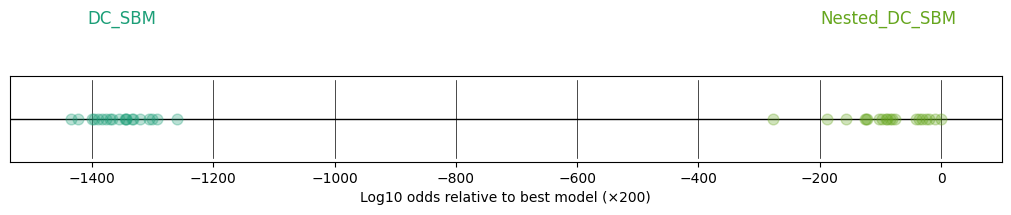

In [25]:
import os
os.makedirs("visual", exist_ok = True)

model_paths = {
    "DC_SBM": f"models/dc_sbm_model_{N_INIT}_min_{MIN_CHANTS_PER_SOURCE}.pickle",
    "Nested_DC_SBM": f"models/nested_dc_sbm_model_{N_INIT}_min_{MIN_CHANTS_PER_SOURCE}.pickle"
}

entropies = load_models(model_paths)
log_odds = compute_log_odds(entropies)
plot_model_comparison(log_odds, f"visual/model_comparison_{N_INIT}_min_{MIN_CHANTS_PER_SOURCE}.pdf")